In [1]:

import sys
sys.path.append("C:\scripts\Imaging analysis")
sys.path.append("C:\scripts\Imaging analysis\src")
import numpy as np
import scipy.io as scio
import matplotlib.pyplot as plt
from alm_2p import session
from matplotlib.pyplot import figure
from numpy import concatenate as cat
from sklearn.preprocessing import normalize
import quality
from scipy import stats
from scipy.stats import zscore
from activityMode import Mode
cat = np.concatenate

plt.rcParams['pdf.fonttype'] = '42' 

# Perturbation analysis

Show individual traces in the before and after subtraction of laser transient in CW32 FOV

In [29]:
# Ipsi paths w subtracted backgrounds:
paths = [r'F:\data\BAYLORCW032\python\2023_10_23',
         r'F:\data\BAYLORCW036\python\2023_10_20',
         r'F:\data\BAYLORCW034\python\2023_10_24',
         r'F:\data\BAYLORCW035\python\2023_12_06',
         r'F:\data\BAYLORCW037\python\2023_11_22'
         ]

path = r'F:\data\BAYLORCW032\python\2023_10_05'
# path = r'F:\data\BAYLORCW035\python\2023_10_26'
path =  r'F:\data\BAYLORCW037\python\2023_11_22'
# path = r'F:\data\BAYLORCW032\python\2023_10_23'

l1 = session.Session(path, #layer_num=1, 
                    use_background_sub=True,
                    baseline_normalization="dff_avg")

Using subtracted background dataset
Minimum cutoff is 61
No water leak!
normalizing
0.22219226
0.22219226
Using Pearsons corr to filter neurons.


In [ ]:
    x, _ = l1.get_trace_matrix_multiple(l1.good_neurons)

In [12]:
# f = plt.figure(figsize=(10,10))
# stim_trials = np.where(l1.stim_ON)[0]

# start_time = l1.delay-int(3/l1.fs)
# end_time = l1.delay + int(4/l1.fs)

# counter = 0
# for trial in stim_trials:
#     y_offset = counter * 4 # Offset increases per trial (you could multiply for bigger spread)
#     x, _ = l1.get_trace_matrix_multiple(l1.good_neurons)
#     plt.plot(x[0][trial][layer,start_time:end_time] + y_offset)
#     plt.axvline(x=l1.delay-start_time, c='b', linewidth = 0.5)
#     plt.axvline(x=l1.delay + int(1/l1.fs)-start_time, c='b', linewidth = 0.5)
#     counter += 1

# plt.title('Layer {}'.format(layer + 1) + ' Background noise')
# plt.show()


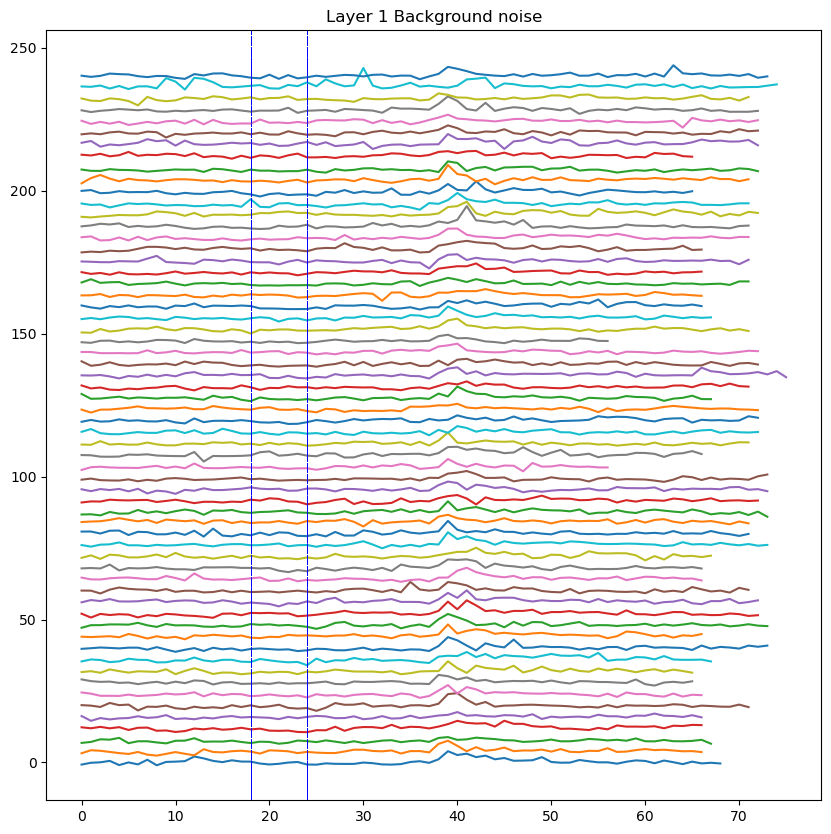

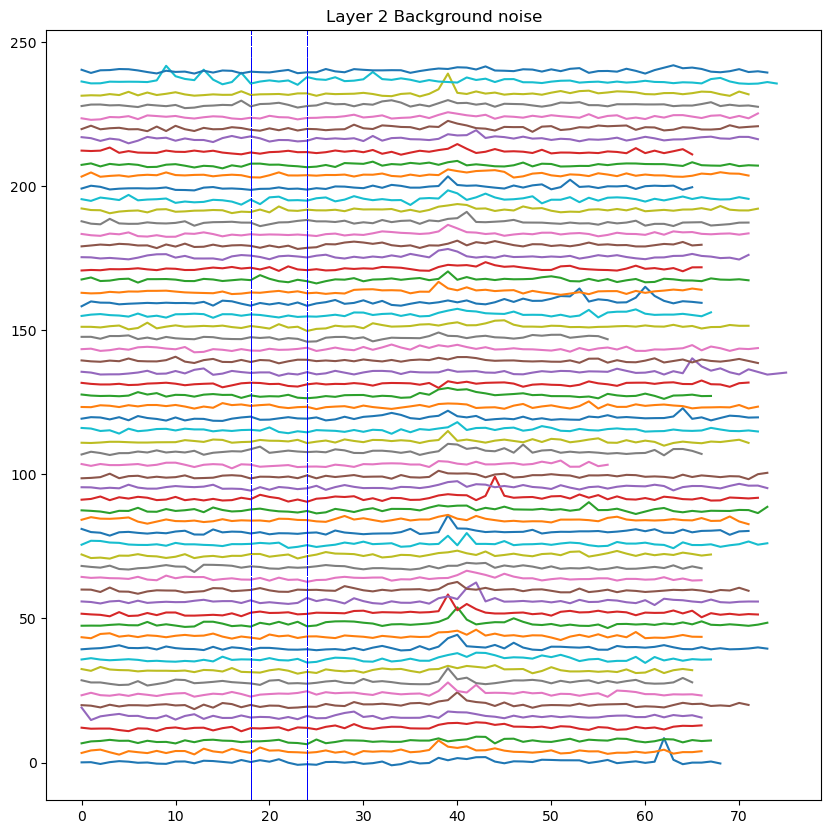

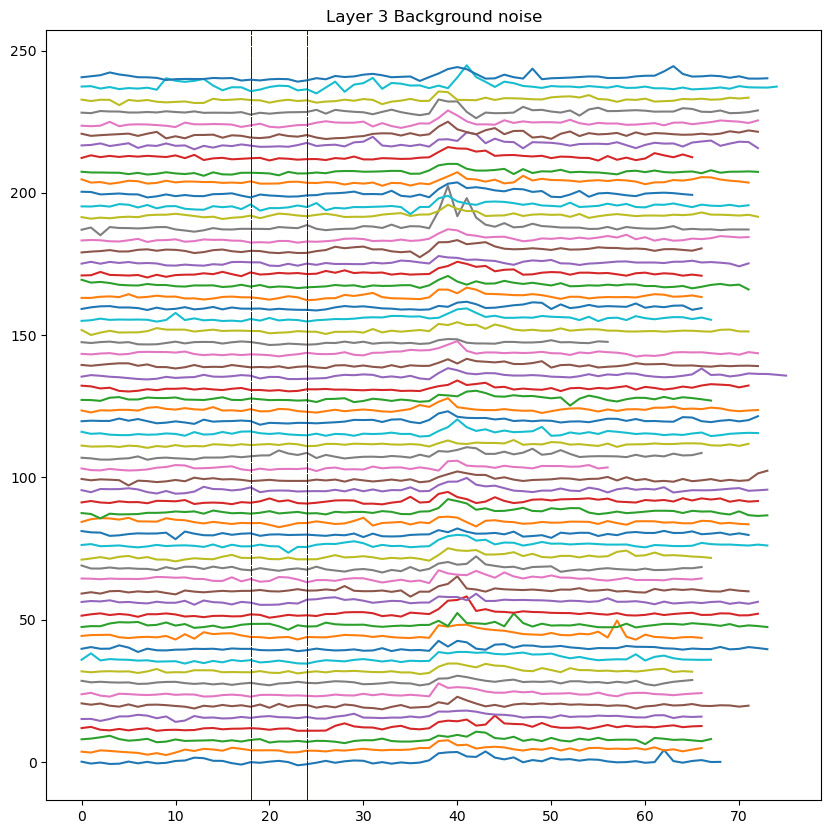

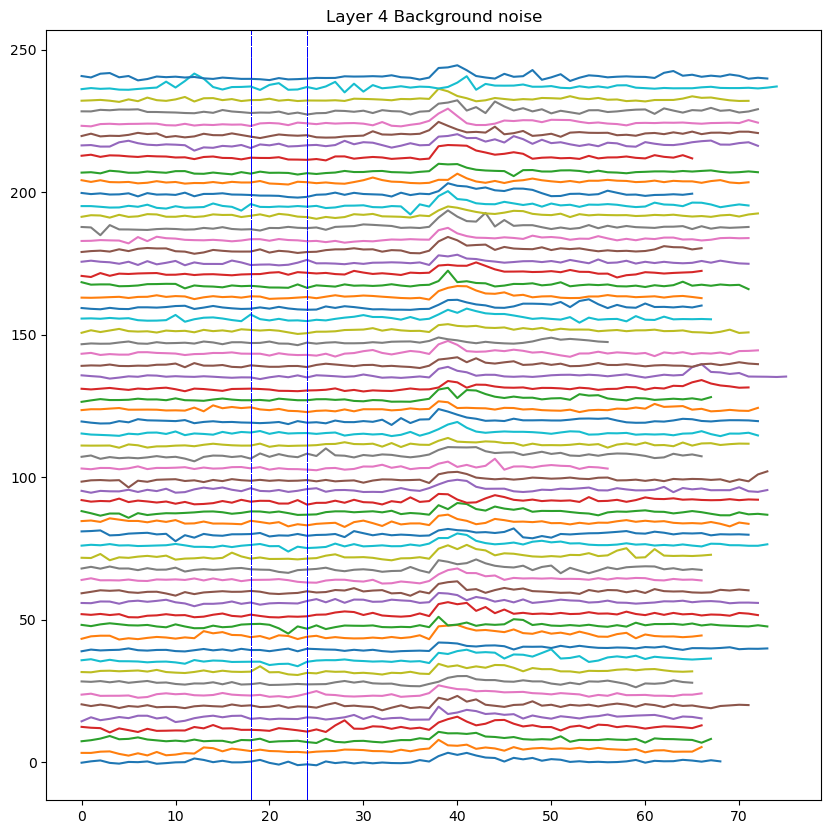

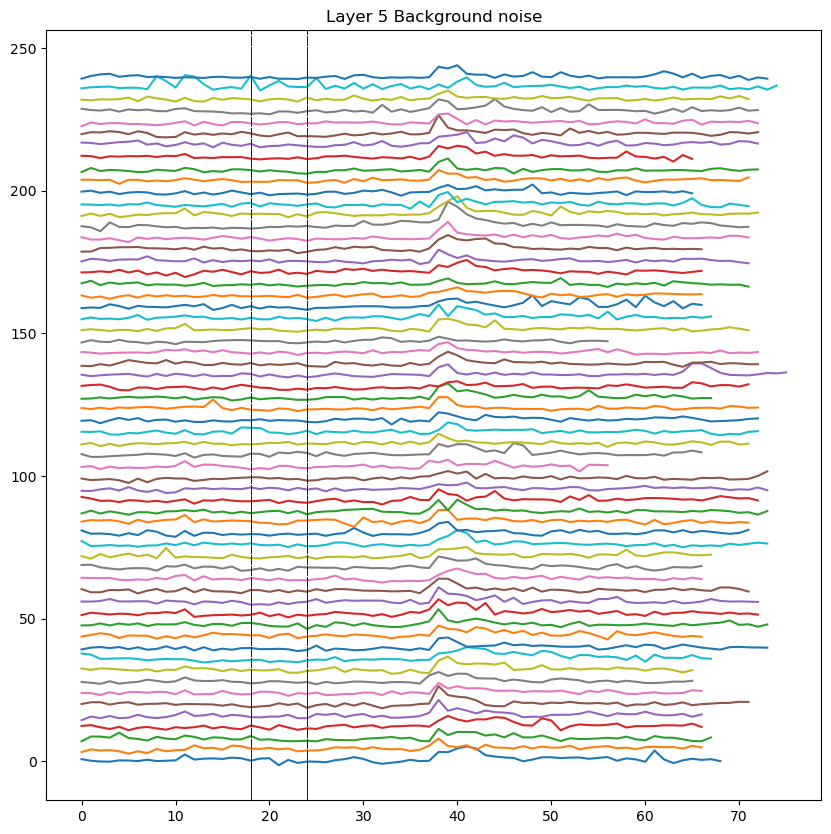

In [30]:
# Plot the background measure
x = l1.background
stim_trials = np.where(l1.stim_ON)[0]
early_lick = np.where(l1.early_lick)[0]
stim_trials = [n for n in stim_trials if n not in early_lick]
layer = 4
for layer in range(5):
    f = plt.figure(figsize=(10,10))
    start_time = l1.delay-int(3/l1.fs)
    end_time = l1.delay + int(15/l1.fs)

    counter = 0
    for trial in stim_trials:
        y_offset = counter * 4 # Offset increases per trial (you could multiply for bigger spread)
        plt.plot(x[0][trial][layer,start_time:end_time] + y_offset)
        plt.axvline(x=l1.delay-start_time, c='b', ls='--', linewidth = 0.5)
        plt.axvline(x=l1.delay + int(1/l1.fs)-start_time, c='b', ls='--', linewidth = 0.5)
        counter += 1

    plt.title('Layer {}'.format(layer + 1) + ' Background noise')
    plt.show()

    

In [22]:
l1.response

40

Heatmap and time course trace of dF/F0 for ipsi opto FOVs early vs late learning

In [41]:
paths = [r'F:\data\BAYLORCW032\python\2023_10_23',
         r'F:\data\BAYLORCW036\python\2023_10_20',
         r'F:\data\BAYLORCW034\python\2023_10_24',
         r'F:\data\BAYLORCW035\python\2023_12_06',
         r'F:\data\BAYLORCW037\python\2023_11_22'
         ]
         
late_ipsi_paths = [r'F:\data\BAYLORCW032\python\2023_10_23',
         r'F:\data\BAYLORCW036\python\2023_10_20',
         r'F:\data\BAYLORCW034\python\2023_10_24',
         r'F:\data\BAYLORCW035\python\2023_12_06',
         # r'F:\data\BAYLORCW037\python\2023_11_22'
         ]

early_ipsi_paths =  [r'F:\data\BAYLORCW032\python\2023_10_11',
                     r'F:\data\BAYLORCW036\python\2023_10_07',
                     r'F:\data\BAYLORCW034\python\2023_10_10',
                     r'F:\data\BAYLORCW035\python\2023_10_27',
                     ]

Using subtracted background dataset
No mod layer, altering to no subtracted background
Minimum cutoff is 61


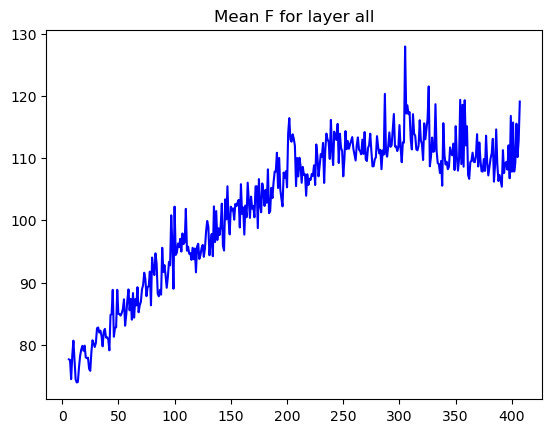

No water leak!
normalizing
-0.5270663
-0.5270663
Using Pearsons corr to filter neurons.


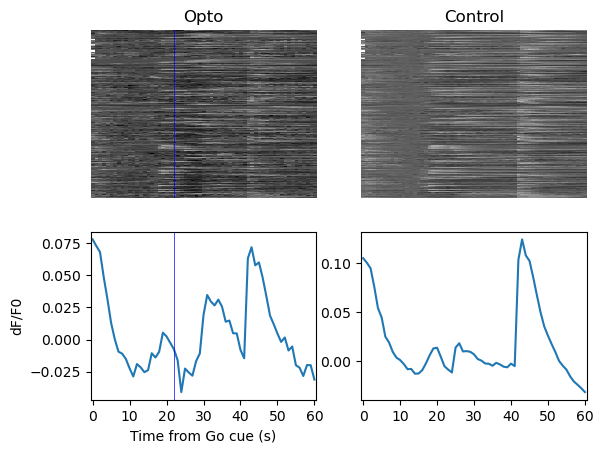

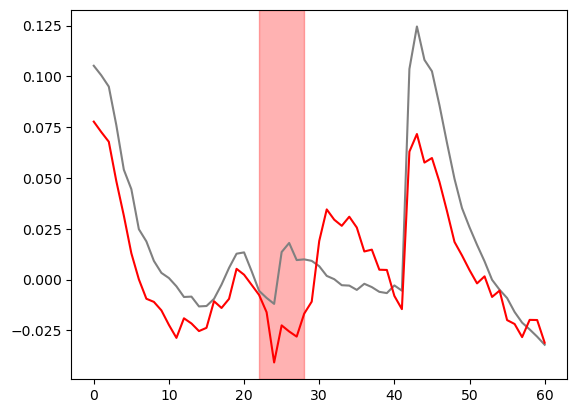

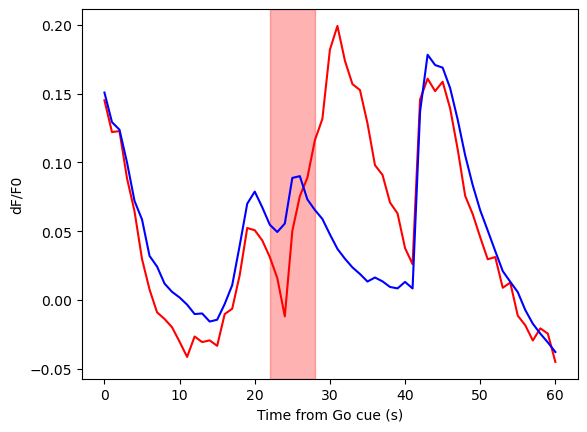

Using subtracted background dataset
No mod layer, altering to no subtracted background
Minimum cutoff is 61


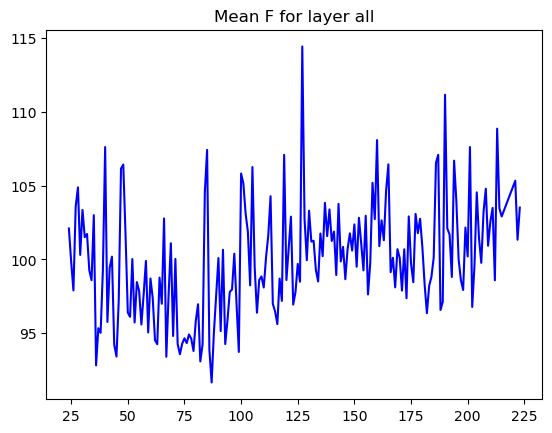

No water leak!
normalizing
4.297355
4.297355
Using Pearsons corr to filter neurons.


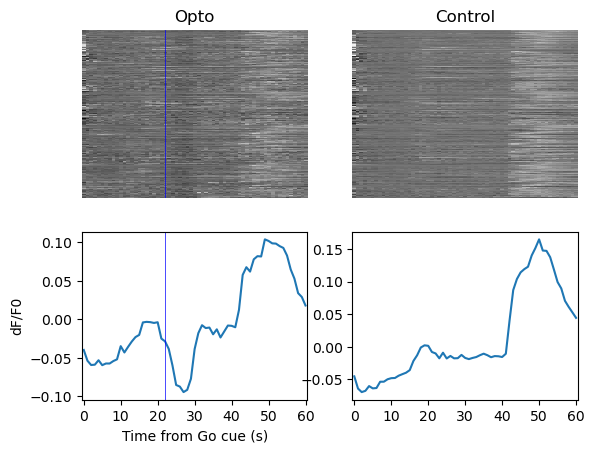

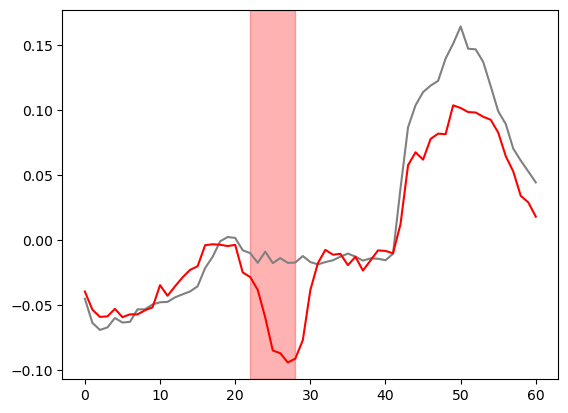

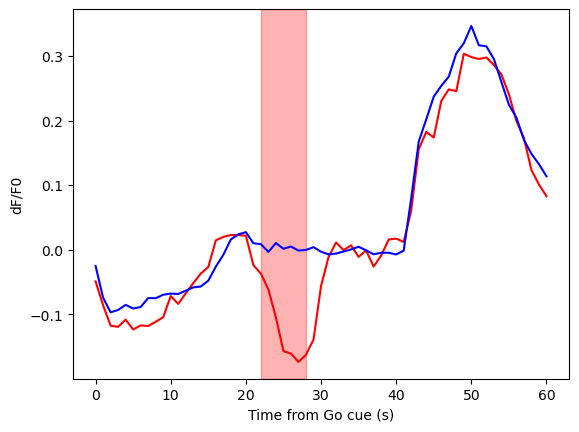

Using subtracted background dataset
No mod layer, altering to no subtracted background
Minimum cutoff is 61


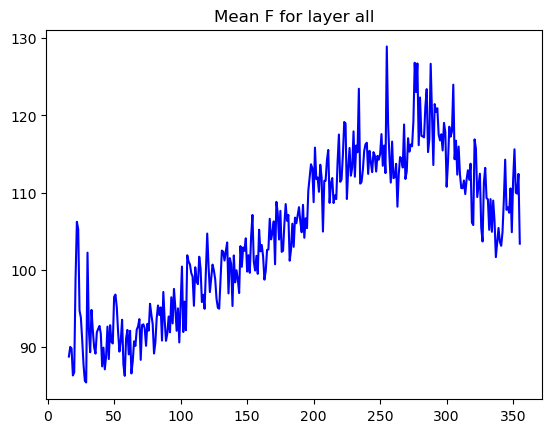

No water leak!
normalizing
-0.17722104
-0.17722104
Using Pearsons corr to filter neurons.


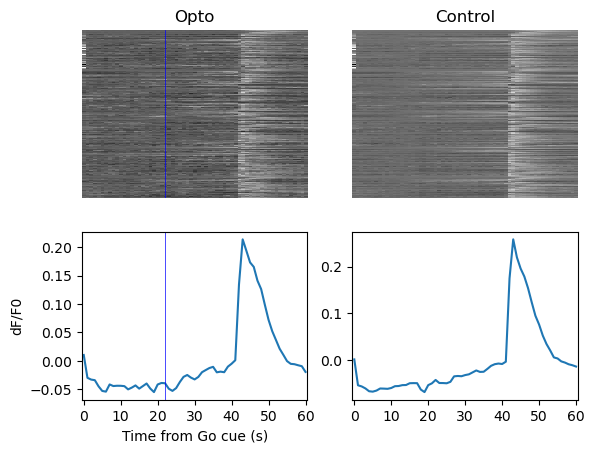

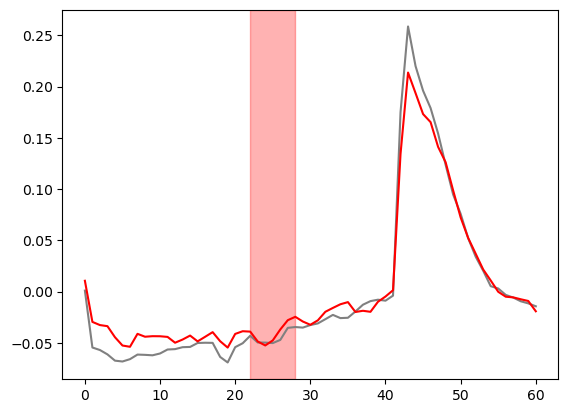

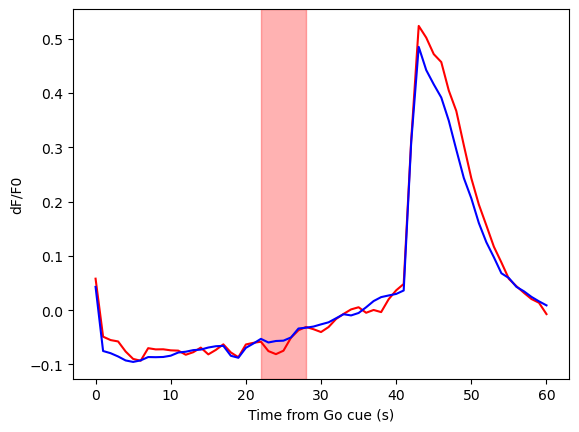

Using subtracted background dataset
No mod layer, altering to no subtracted background
Minimum cutoff is 61


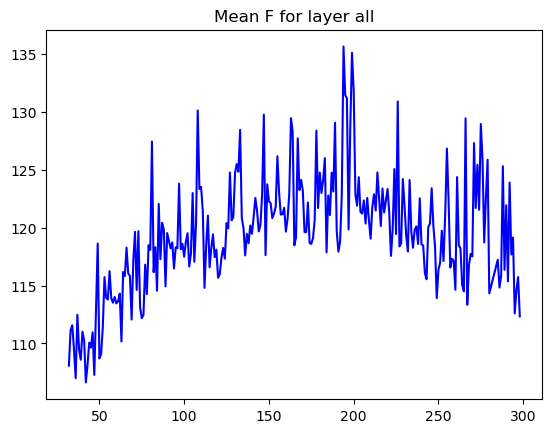

No water leak!
normalizing
-0.9909165
-0.9909165
Using Pearsons corr to filter neurons.


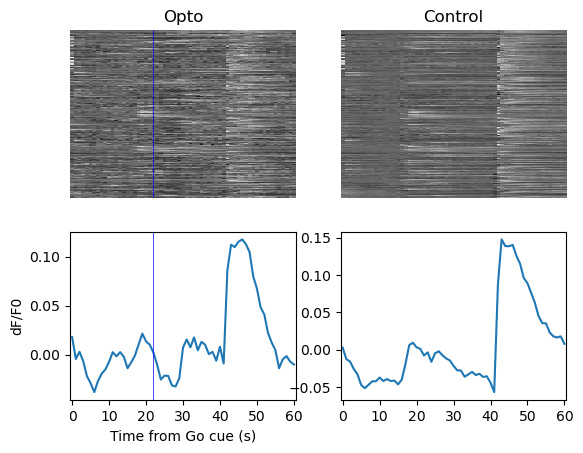

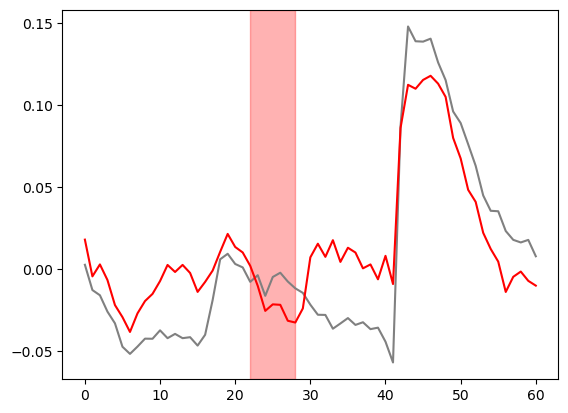

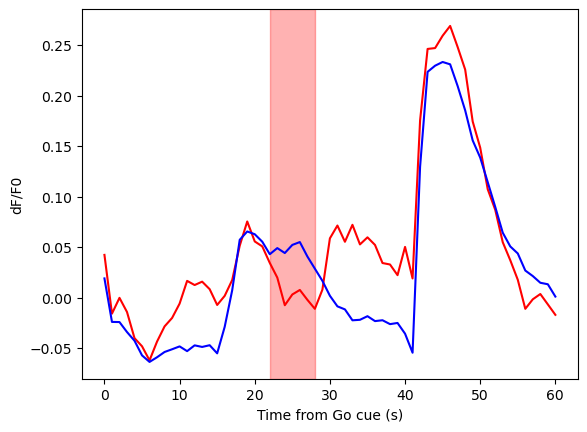

Using subtracted background dataset
Minimum cutoff is 61


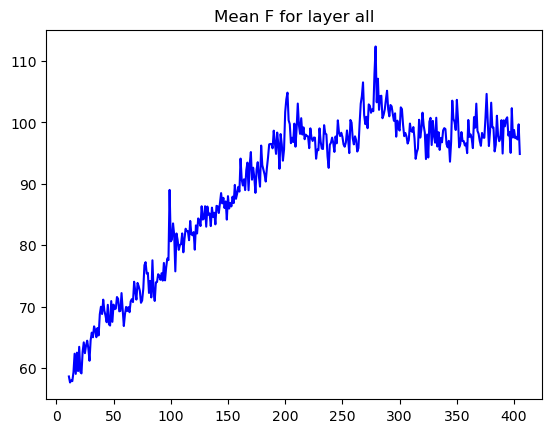

No water leak!
normalizing
-0.9560069
-0.9560069
Using Pearsons corr to filter neurons.


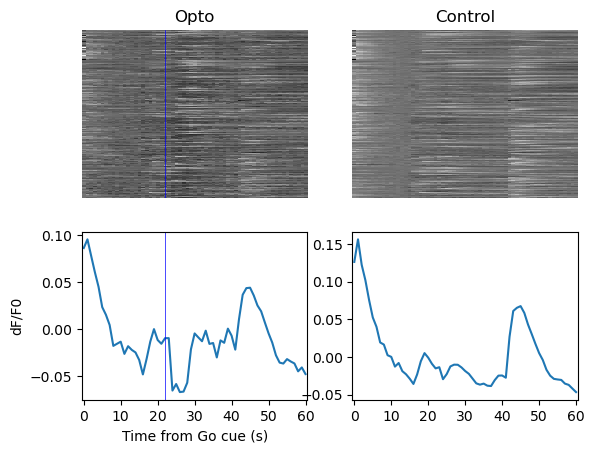

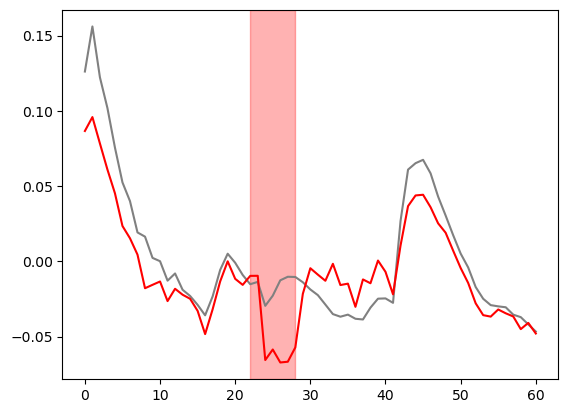

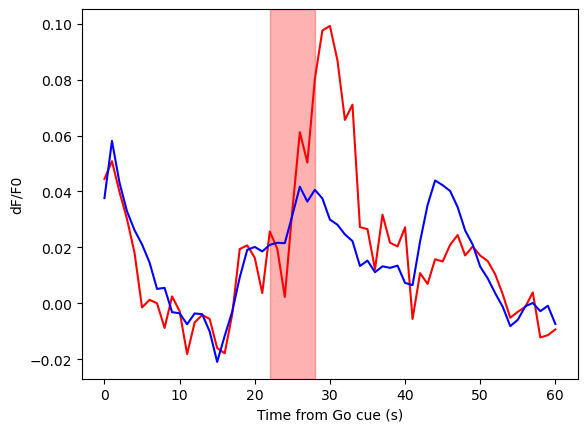

Using subtracted background dataset
Minimum cutoff is 61


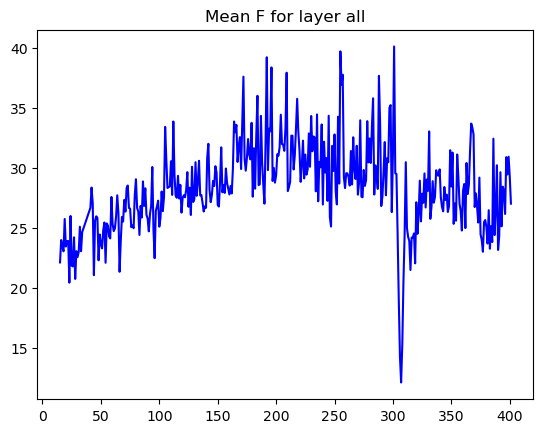

No water leak!
normalizing
-0.16076258
-0.16076258
Using Pearsons corr to filter neurons.


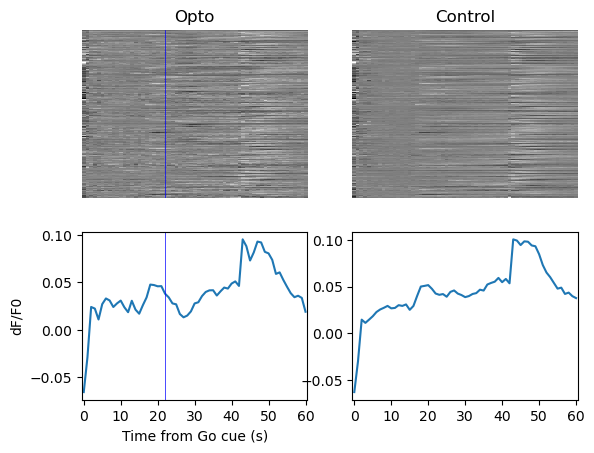

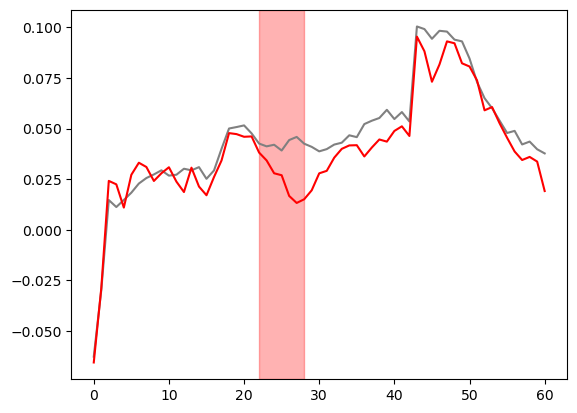

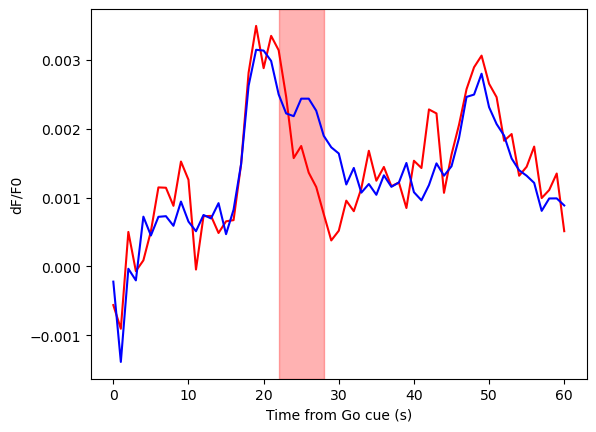

Using subtracted background dataset
Minimum cutoff is 61


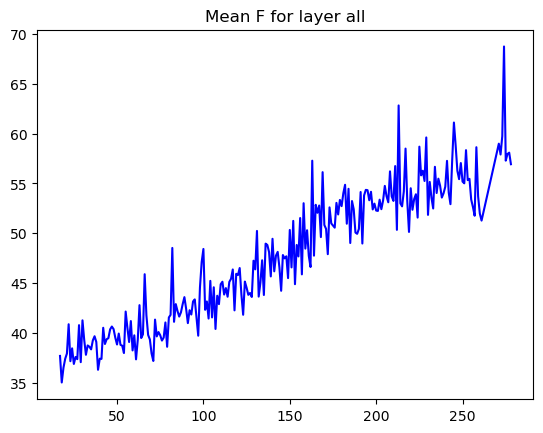

No water leak!
normalizing
0.70975935
0.70975935
Using Pearsons corr to filter neurons.


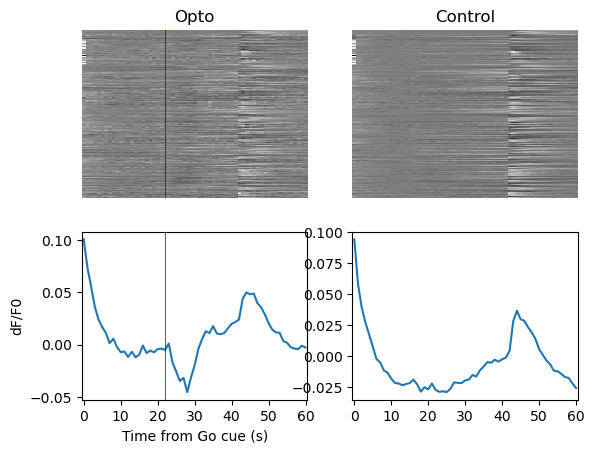

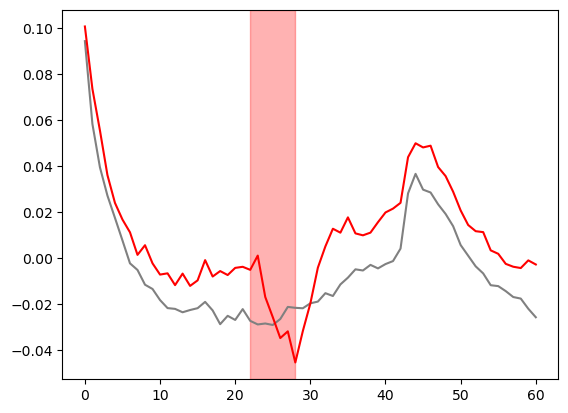

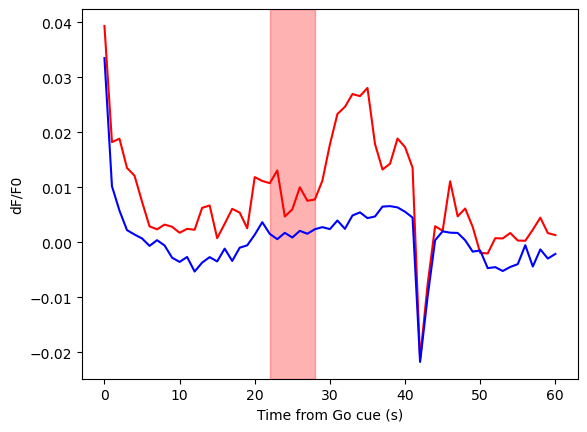

Using subtracted background dataset
Minimum cutoff is 61


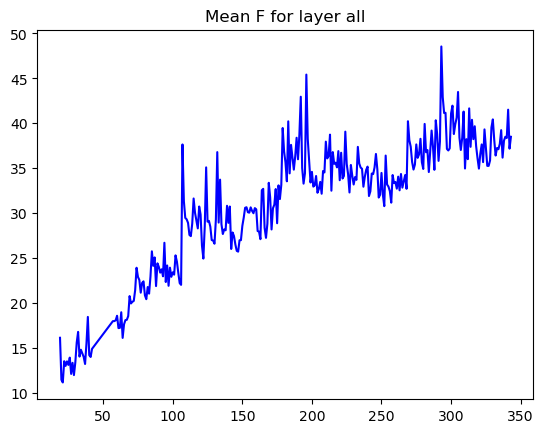

No water leak!
normalizing
-1.0917112
-1.0917112
Using Pearsons corr to filter neurons.


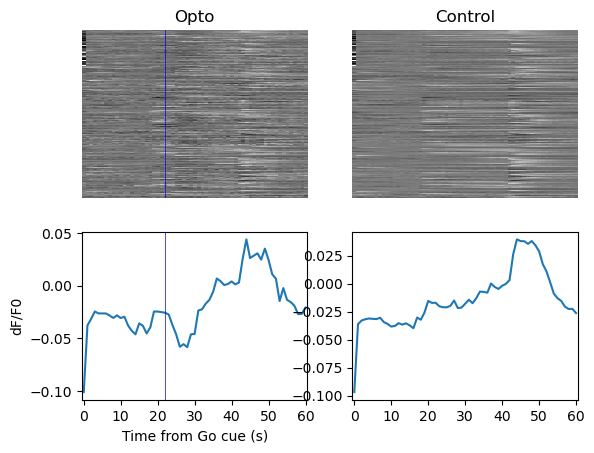

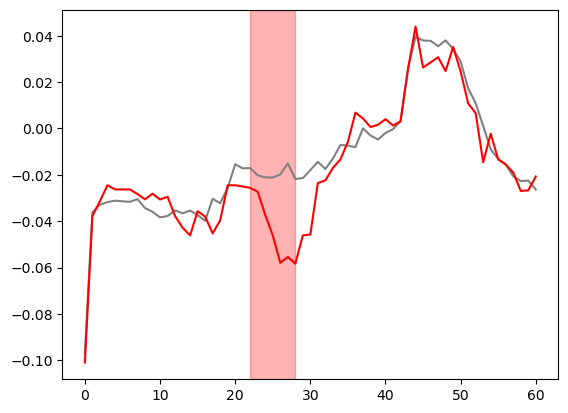

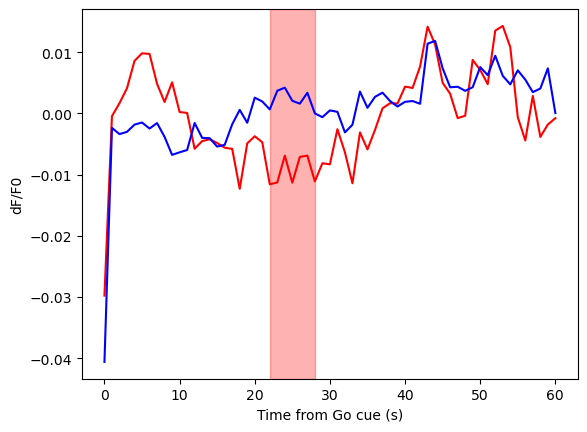

In [42]:
allstack, allcontrastimstack = np.zeros(26), np.zeros(26)
# allstack, allcontrastimstack = np.zeros(20), np.zeros(20)

for path in early_ipsi_paths:
    
    l1 = quality.QC(path, use_background_sub=True)

    stack, stimstack = l1.all_neurons_heatmap(return_traces=True)
    
    normstack = normalize(np.hstack((stimstack,stack)))
    stimstack = normstack[:, :61]
    stack = normstack[:, 61:]
    
    allstack = np.vstack((allstack, stack[:, 12:38]))
    allcontrastimstack = np.vstack((allcontrastimstack, stimstack[:, 12:38]))
    
    # allstack = np.vstack((allstack, normalize(stack)[:, 12:38]))
    # allcontrastimstack = np.vstack((allcontrastimstack, normalize(stimstack)[:, 12:38]))
    
    # allstack = np.vstack((allstack, zscore(stack ,axis=0)))
    # allcontrastimstack = np.vstack((allcontrastimstack, zscore(stimstack, axis=0)))
    
# allstack = allstack[1:,12:38]
# allcontrastimstack = allcontrastimstack[1:,12:38]
allstack = allstack[1:]
allcontrastimstack = allcontrastimstack[1:]

diffs = []

for neuron in range(allcontrastimstack.shape[0]):
    

    postdelay = np.mean(allcontrastimstack[neuron, l1.delay-10:l1.delay-8])
    predelay = np.mean(allcontrastimstack[neuron, l1.delay-12:l1.delay-10])
    
    diffs += [predelay - postdelay]

ordering = np.argsort(diffs)
allcontrastimstack_sorted = np.take(allcontrastimstack, ordering, axis=0)


allstack_late, allcontrastimstack_late = np.zeros(26), np.zeros(26)
# allstack, allcontrastimstack = np.zeros(20), np.zeros(20)

for path in late_ipsi_paths:
    
    l1 = quality.QC(path, use_background_sub=True)

    stack, stimstack = l1.all_neurons_heatmap(return_traces=True)
    
    normstack = normalize(np.hstack((stimstack,stack)))
    stimstack = normstack[:, :61]
    stack = normstack[:, 61:]
    
    allstack_late = np.vstack((allstack_late, stack[:, 12:38]))
    allcontrastimstack_late = np.vstack((allcontrastimstack_late, stimstack[:, 12:38]))
    
    # allstack = np.vstack((allstack, normalize(stack)[:, 12:38]))
    # allcontrastimstack = np.vstack((allcontrastimstack, normalize(stimstack)[:, 12:38]))
    
    # allstack = np.vstack((allstack, zscore(stack ,axis=0)))
    # allcontrastimstack = np.vstack((allcontrastimstack, zscore(stimstack, axis=0)))
    
# allstack = allstack[1:,12:38]
# allcontrastimstack = allcontrastimstack[1:,12:38]
allstack_late = allstack_late[1:]
allcontrastimstack_late = allcontrastimstack_late[1:]

diffs = []

for neuron in range(allcontrastimstack_late.shape[0]):
    

    postdelay = np.mean(allcontrastimstack_late[neuron, l1.delay-10:l1.delay-8])
    predelay = np.mean(allcontrastimstack_late[neuron, l1.delay-12:l1.delay-10])
    
    diffs += [predelay - postdelay]

ordering = np.argsort(diffs)
allcontrastimstack_sorted_late = np.take(allcontrastimstack_late, ordering, axis=0)

In [43]:
# Normmalize the stack

allcontrastimstack_sorted_norm = normalize(allcontrastimstack_sorted)
allcontrastimstack_sorted_late_norm = normalize(allcontrastimstack_sorted_late)

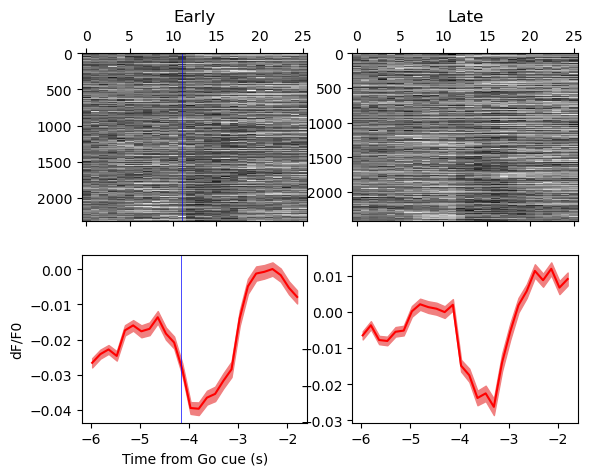

In [49]:



x = np.arange(-7.97,4,l1.fs)[12:38]
# # x = np.arange(-6.97,4,self.fs)[:self.time_cutoff]
# # allstack = normalize(allstack)
# # allstimstack = normalize(allstimstack)
# plt.figure(figsize=(8,5))
# # plt.matshow(allcontrastimstack, cmap='gray', fignum=1, aspect='auto')
# plt.matshow(allcontrastimstack_sorted, cmap='gray', fignum=1, aspect='auto')
# plt.xticks(range(0,38-12, 6), [int(d) for d in x[::6]])
# plt.axvline(x=l1.delay-10, c='b', linewidth = 0.5)
# plt.show()

f, axarr = plt.subplots(2,2)# sharey='row')#, sharex='col')

axarr[0,0].matshow(allcontrastimstack_sorted_norm, cmap='gray', interpolation='nearest', aspect='auto')
# axarr[0,0].axis('off')
# axarr[0,0].set_xticks(range(0,38-12, 6), [int(d) for d in x[::6]])
# 
axarr[0,0].set_title('Early')
axarr[0,0].axvline(x=l1.delay-11, c='b', linewidth = 0.5)
# axarr[0,0].axvline(x=-3, c='b', linewidth = 0.5)

axarr[1,0].plot(x, np.mean(allcontrastimstack_sorted, axis = 0), color = 'red')
axarr[1,0].fill_between(x, np.mean(allcontrastimstack_sorted, axis = 0) - stats.sem(allcontrastimstack_sorted, axis=0), 
          np.mean(allcontrastimstack_sorted, axis = 0) + stats.sem(allcontrastimstack_sorted, axis=0),
          color='lightcoral')   
# axarr[1,0].set_ylim(top=self.fs)
# axarr[1,0].axvline(x=l1.delay-6, c='b', linewidth = 0.5)
axarr[1,0].axvline(x=-4.16, c='b', linewidth = 0.5)
# axarr[1,0].set_xticks(range(0,allstack.shape[1], 10), [int(d) for d in x[::10]])

axarr[0,1].matshow(allcontrastimstack_sorted_late_norm, cmap='gray', interpolation='nearest', aspect='auto')
# axarr[0,1].axis('off')
# axarr[0,1].set_xticks(range(0,38-12, 6), [int(d) for d in x[::6]])

axarr[0,1].set_title('Late')

axarr[1,1].plot(x, np.mean(allcontrastimstack_sorted_late, axis = 0), color = 'red')

axarr[1,1].fill_between(x, np.mean(allcontrastimstack_sorted_late, axis = 0) - stats.sem(allcontrastimstack_sorted_late, axis=0), 
          np.mean(allcontrastimstack_sorted_late, axis = 0) + stats.sem(allcontrastimstack_sorted_late, axis=0),
          color='lightcoral')   
# axarr[1,1].set_ylim(top=0.2)
axarr[1,0].set_ylabel('dF/F0')
# axarr[1,1].set_xticks(range(0,allstack.shape[1], 10), [int(d) for d in x[::10]])
axarr[1,0].set_xlabel('Time from Go cue (s)')

# plt.suptitle('n=3431 neurons')

plt.savefig(r'P:\paperfigures\fig3\ipsi_early_late_heatmap.pdf')
plt.show()

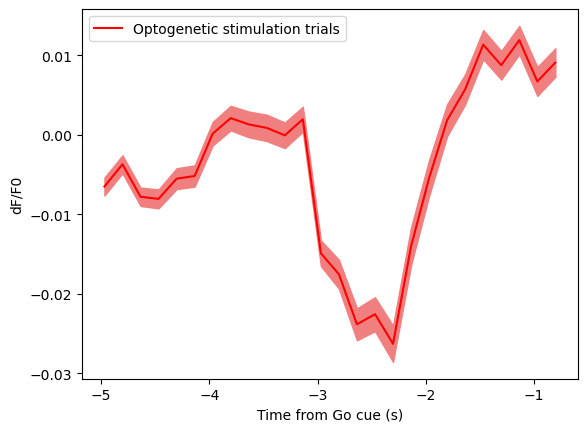

In [6]:
x = np.arange(-6.97,4,l1.fs)[12:38]

plt.plot(x, np.mean(allcontrastimstack, axis = 0), color = 'red', label='Optogenetic stimulation trials')
plt.fill_between(x, np.mean(allcontrastimstack, axis = 0) - stats.sem(allcontrastimstack, axis=0), 
          np.mean(allcontrastimstack, axis = 0) + stats.sem(allcontrastimstack, axis=0),
          color='lightcoral')   

# plt.plot(x, np.mean(allstack, axis = 0), color = 'grey', label='Control trials')
# plt.axvline(x=-3, c='b', linewidth = 0.5)
# plt.fill_between(x, np.mean(allstack, axis = 0) - stats.sem(allstack, axis=0), 
#           np.mean(allstack, axis = 0) + stats.sem(allstack, axis=0),
#           color='silver')   

# plt.plot(x, np.mean(allstack, axis = 0)+0.04, color = 'grey', label='Control trials')
# plt.axvline(x=-3, c='b', linewidth = 0.5)
# plt.fill_between(x, np.mean(allstack, axis = 0)+0.04 - stats.sem(allstack, axis=0), 
#           np.mean(allstack, axis = 0) +0.04+ stats.sem(allstack, axis=0),
#           color='silver')   


# axarr[1,1].set_ylim(top=0.2)
plt.ylabel('dF/F0')
# axarr[1,1].set_xticks(range(0,allstack.shape[1], 10), [int(d) for d in x[::10]])
plt.xlabel('Time from Go cue (s)')
# plt.ylim(-0.04,0.01) # for comparison to ipsi
# plt.ylim(-0.13, -0.04) # for compariosn to subtract background
plt.legend()
# plt.savefig(r'F:\data\Fig 3\contra_opto_effect_overlay_subtractbackground.pdf')

plt.show()

In [48]:
allcontrastimstack_sorted.shape, x.shape

((2322, 26), (1, 396))

bar plot: Effect of ipsi silencing over non-matched FOVs early vs late learning

Using subtracted background dataset
No mod layer, altering to no subtracted background
Minimum cutoff is 61


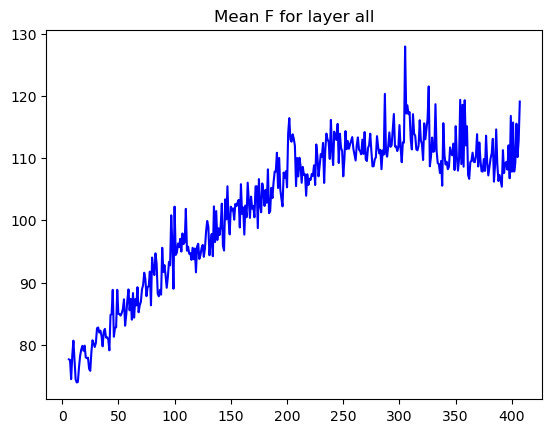

No water leak!
normalizing
-1.0003314
-1.0003314
Using Pearsons corr to filter neurons.
Using subtracted background dataset
No mod layer, altering to no subtracted background
Minimum cutoff is 61


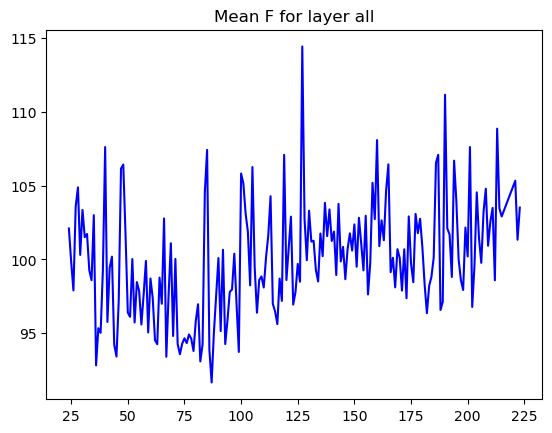

No water leak!
normalizing
20.221882
20.221882
Using Pearsons corr to filter neurons.
Using subtracted background dataset
No mod layer, altering to no subtracted background
Minimum cutoff is 61


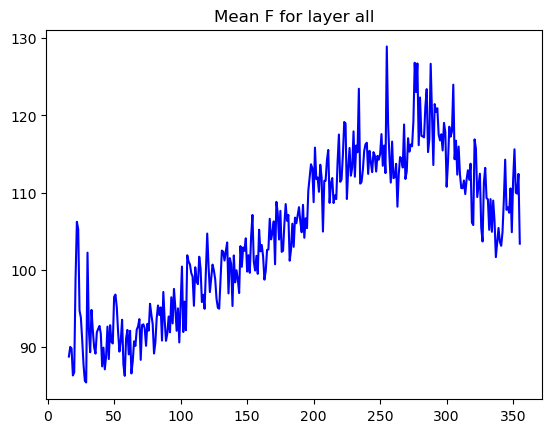

No water leak!
normalizing
1.2503798
1.2503798
Using Pearsons corr to filter neurons.
Using subtracted background dataset
No mod layer, altering to no subtracted background
Minimum cutoff is 61


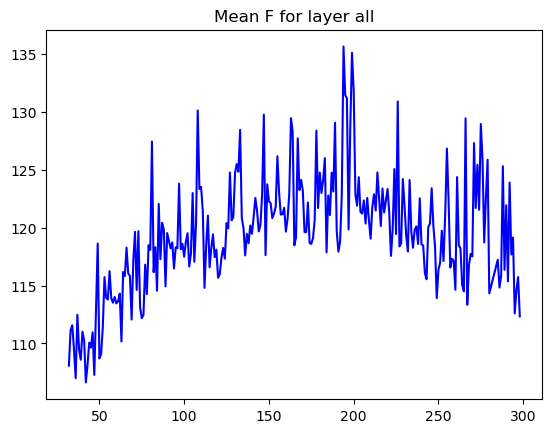

No water leak!
normalizing
-7.0975103
-7.0975103
Using Pearsons corr to filter neurons.
Using subtracted background dataset
Minimum cutoff is 61


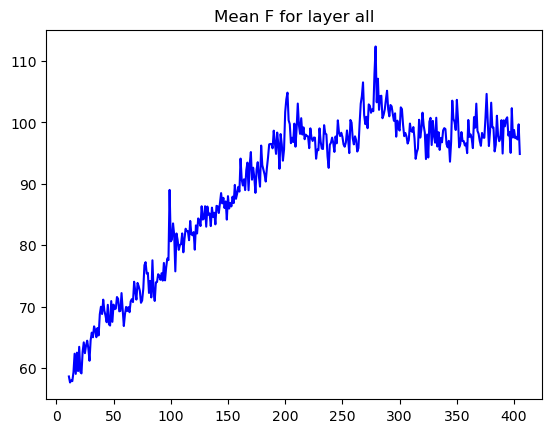

No water leak!
normalizing
-3.348098
-3.348098
Using Pearsons corr to filter neurons.
Using subtracted background dataset
Minimum cutoff is 61


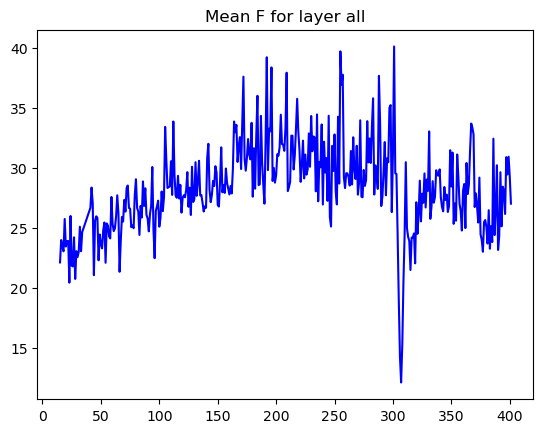

No water leak!
normalizing
0.8580999
0.8580999
Using Pearsons corr to filter neurons.
Using subtracted background dataset
Minimum cutoff is 61


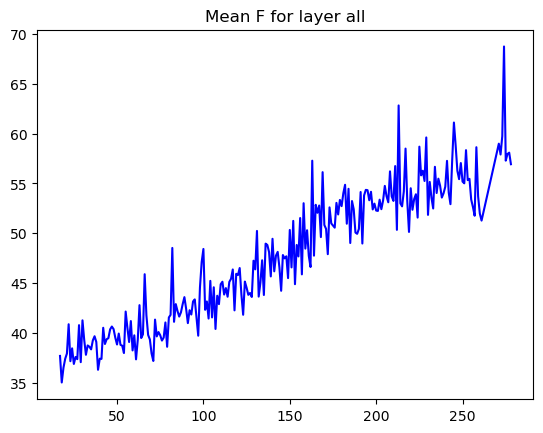

No water leak!
normalizing
1.054869
1.054869
Using Pearsons corr to filter neurons.
Using subtracted background dataset
Minimum cutoff is 61


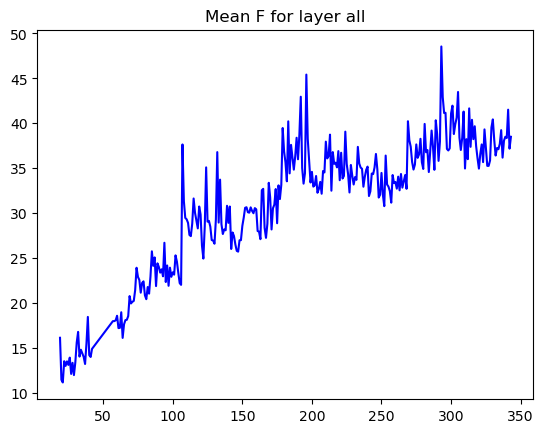

No water leak!
normalizing
-3.7107441
-3.7107441
Using Pearsons corr to filter neurons.


In [36]:
late_ipsi_paths = [r'F:\data\BAYLORCW032\python\2023_10_23',
         r'F:\data\BAYLORCW036\python\2023_10_20',
         r'F:\data\BAYLORCW034\python\2023_10_24',
         r'F:\data\BAYLORCW035\python\2023_12_06',
         # r'F:\data\BAYLORCW037\python\2023_11_22'
         ]

early_ipsi_paths =  [r'F:\data\BAYLORCW032\python\2023_10_11',
                     r'F:\data\BAYLORCW036\python\2023_10_07',
                     r'F:\data\BAYLORCW034\python\2023_10_10',
                     r'F:\data\BAYLORCW035\python\2023_10_27',
                     ]
ipsi_paths = [early_ipsi_paths, late_ipsi_paths]

allsup, allexc=[],[]
for paths in ipsi_paths:
    contra_frac_sup, contra_frac_exc = [], []

    for path in paths:
    
        l1 = quality.QC(path=path, use_reg=False, triple=False, use_background_sub=True, baseline_normalization="median_zscore")
        
        _, sig_n = l1.stim_effect_per_neuron()
            
        contra_frac_sup += [len(np.where(sig_n < 0)[0]) / len(sig_n)]
        contra_frac_exc += [len(np.where(sig_n > 0)[0]) / len(sig_n)]
        
    allsup += [contra_frac_sup]
    allexc += [contra_frac_exc]
    


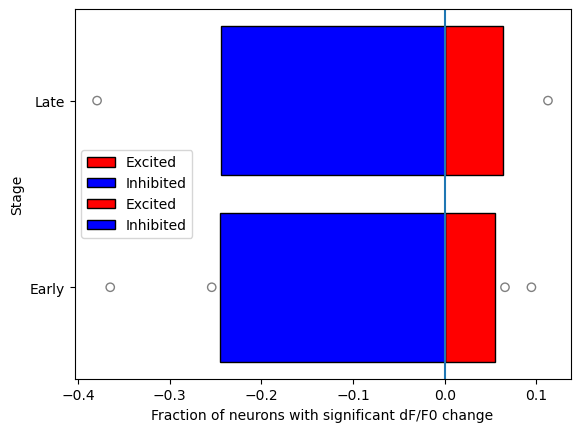

In [37]:
    
    
    
f=plt.figure()

for i in range(2):
    
    plt.scatter(cat((allexc[i], -1 * np.array(allsup[i]))), np.ones(len(cat((allexc[i], allsup[i])))) * (i), facecolors='none', edgecolors='grey')

    plt.barh([i], [np.mean(allexc[i])], color = 'r', edgecolor = 'black', label = 'Excited')
    plt.barh([i], [-np.mean(allsup[i])], color = 'b', edgecolor = 'black', label = 'Inhibited')
    

    
    
plt.axvline(0)
plt.yticks([0,1], ['Early', 'Late'])
plt.ylabel('Stage')
plt.xlabel('Fraction of neurons with significant dF/F0 change')
# plt.title("Perturbation effect over learning (n = {} neurons)".format(total_n))
plt.savefig(r'P:\paperfigures\fig3\silence_ipsi_earlylate.pdf')
plt.legend()

## Bar plot for contra vs ipsi significantly affected neurons:

In [31]:
ipsi_paths = [r'F:\data\BAYLORCW032\python\2023_10_23',
         r'F:\data\BAYLORCW036\python\2023_10_20',
         r'F:\data\BAYLORCW034\python\2023_10_24',
         r'F:\data\BAYLORCW035\python\2023_12_06',
         r'F:\data\BAYLORCW037\python\2023_11_22'
         ]

contra_paths = [
            r'F:\data\BAYLORCW032\python\2023_10_24',
            r'F:\data\BAYLORCW034\python\2023_10_27',
            r'F:\data\BAYLORCW036\python\2023_10_30',
            r'F:\data\BAYLORCW035\python\2023_12_15',
            r'F:\data\BAYLORCW037\python\2023_12_15',
            ]

Using subtracted background dataset
Minimum cutoff is 61


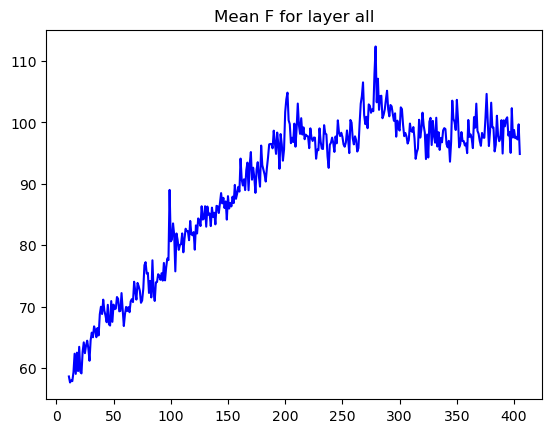

No water leak!
normalizing
-3.348098
-3.348098
Using Pearsons corr to filter neurons.
Using subtracted background dataset
Minimum cutoff is 61


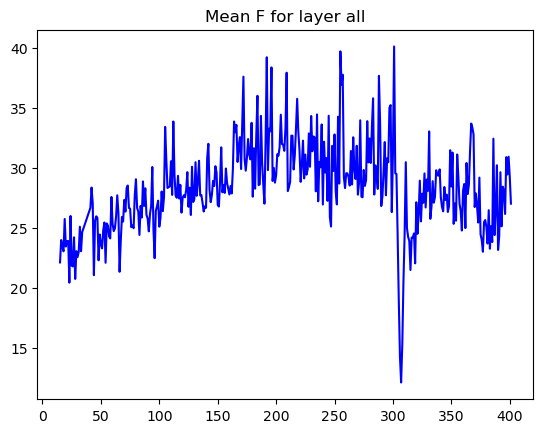

No water leak!
normalizing
0.8580999
0.8580999
Using Pearsons corr to filter neurons.
Using subtracted background dataset
Minimum cutoff is 61


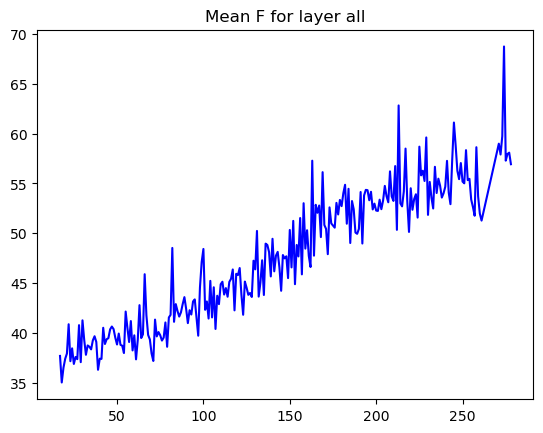

No water leak!
normalizing
1.054869
1.054869
Using Pearsons corr to filter neurons.
Using subtracted background dataset
Minimum cutoff is 61


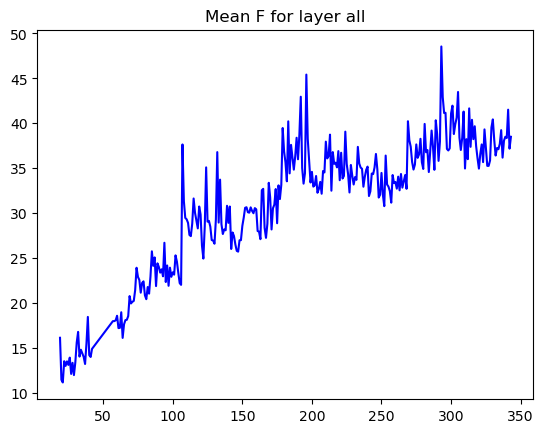

No water leak!
normalizing
-3.7107441
-3.7107441
Using Pearsons corr to filter neurons.
Using subtracted background dataset
Minimum cutoff is 61


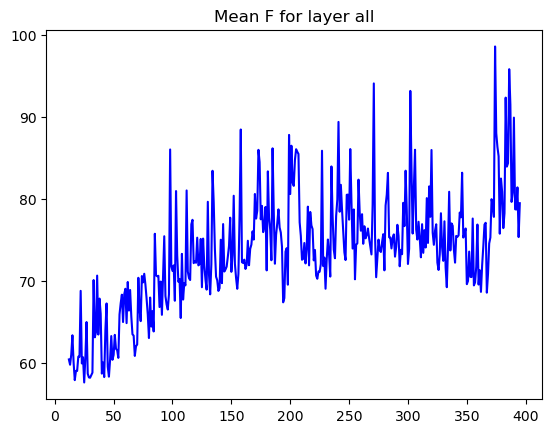

No water leak!
normalizing
2.6138146
2.6138146
Using Pearsons corr to filter neurons.
Using subtracted background dataset
Minimum cutoff is 61


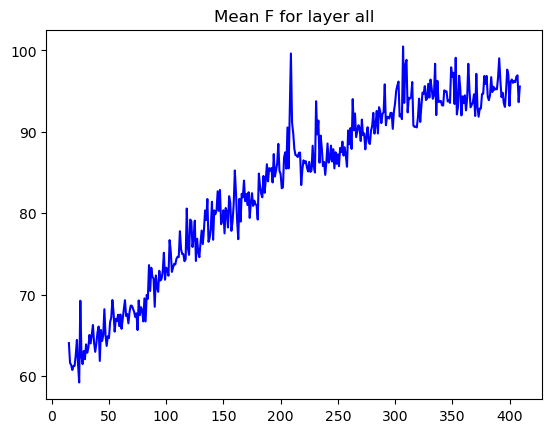

No water leak!
normalizing
5.241595
5.241595
Using Pearsons corr to filter neurons.
Using subtracted background dataset
Minimum cutoff is 61


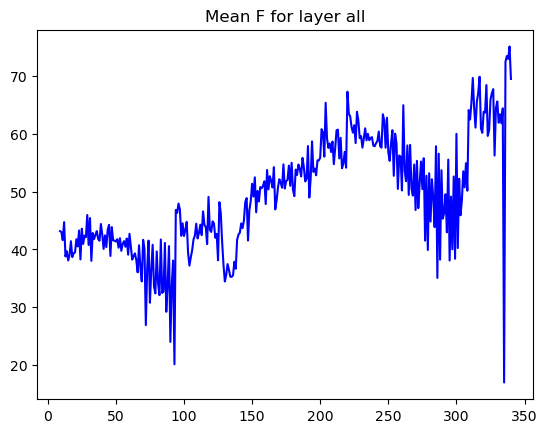

No water leak!
normalizing
1.340113
1.340113
Using Pearsons corr to filter neurons.
Using subtracted background dataset
Minimum cutoff is 61


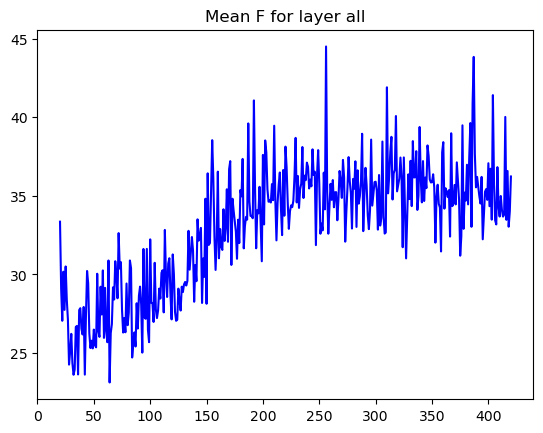

No water leak!
normalizing
-5.020843
-5.020843
Using Pearsons corr to filter neurons.
Using subtracted background dataset
Minimum cutoff is 61


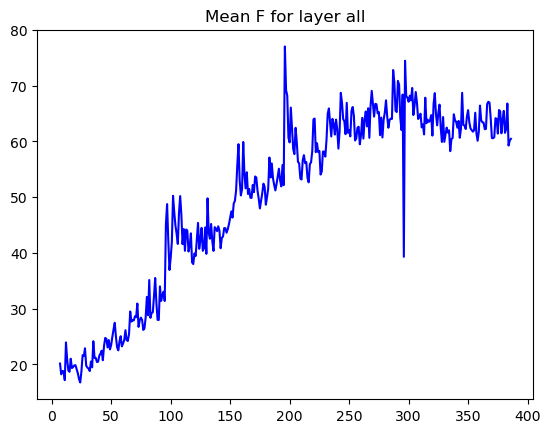

No water leak!
normalizing
-1.0051281
-1.0051281
Using Pearsons corr to filter neurons.
Using subtracted background dataset
Minimum cutoff is 61


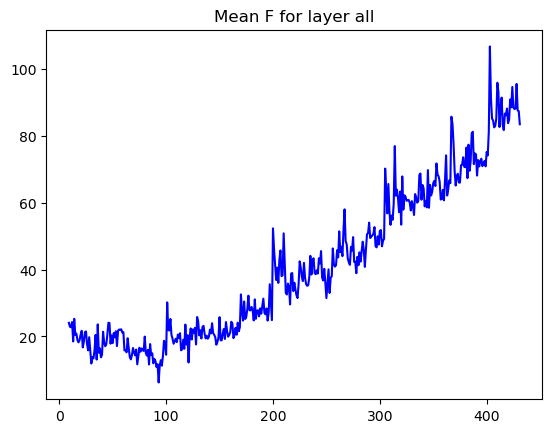

No water leak!
normalizing
-0.3886873
-0.3886873
Using Pearsons corr to filter neurons.


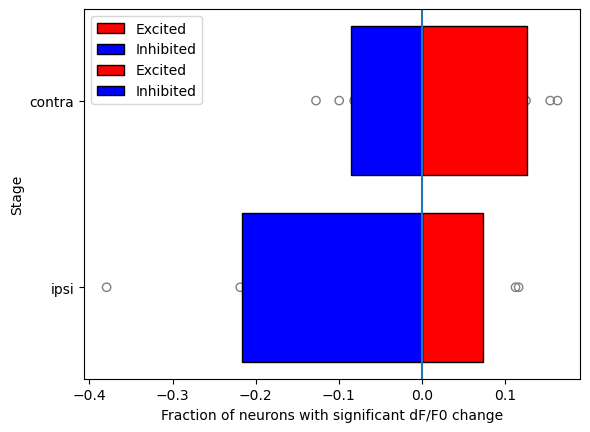

In [ ]:
both_paths = [ipsi_paths, contra_paths]

allsup, allexc=[],[]
for paths in both_paths:
    contra_frac_sup, contra_frac_exc = [], []

    for path in paths:
    
        l1 = quality.QC(path=path, use_reg=False, triple=False, use_background_sub=True, baseline_normalization="median_zscore")
        
        _, sig_n = l1.stim_effect_per_neuron()
            
        contra_frac_sup += [len(np.where(sig_n < 0)[0]) / len(sig_n)]
        contra_frac_exc += [len(np.where(sig_n > 0)[0]) / len(sig_n)]
        
    allsup += [contra_frac_sup]
    allexc += [contra_frac_exc]
    


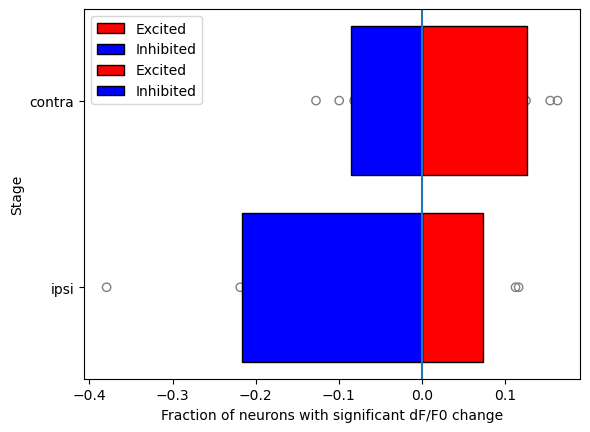

In [34]:
    
    
    
f=plt.figure()

for i in range(2):
    
    plt.scatter(cat((allexc[i], -1 * np.array(allsup[i]))), np.ones(len(cat((allexc[i], allsup[i])))) * (i), facecolors='none', edgecolors='grey')

    plt.barh([i], [np.mean(allexc[i])], color = 'r', edgecolor = 'black', label = 'Excited')
    plt.barh([i], [-np.mean(allsup[i])], color = 'b', edgecolor = 'black', label = 'Inhibited')
    

    
    
plt.axvline(0)
plt.yticks([0,1], ['ipsi', 'contra'])
plt.ylabel('Stage')
plt.xlabel('Fraction of neurons with significant dF/F0 change')
# plt.title("Perturbation effect over learning (n = {} neurons)".format(total_n))
plt.savefig(r'P:\paperfigures\fig3\silence_contra_ipsi_n.pdf')
plt.legend()